# PhishRAG — Phishing Email Classification Pipeline

**Input files required:**
- `phishing_legit_dataset_KD_10000.csv` — original labeled email dataset

**Output:**
- `features.csv` — engineered feature matrix
- `tfidf_vocabulary.pkl` — fixed TF-IDF vocabulary
- `model_a_binary.pkl` / `model_b_type.pkl` / `model_c_severity.pkl` — trained models
- Three output labels per email: `is_phishing` / `phishing_type` / `severity`

**Pipeline structure:**
- Cell Group A: Feature Engineering
- Cell Group B: Model Training + Evaluation
- Cell Group C: Inference Function

---
## Cell Group A: Feature Engineering

### A1. Install & Import

In [1]:
!pip install xgboost shap scikit-learn pandas numpy matplotlib seaborn joblib scipy -q


In [2]:
import re
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, accuracy_score, f1_score
)
from xgboost import XGBClassifier

print('All imports OK')


All imports OK


### A2. Load Raw Data

In [4]:
df = pd.read_csv('phishing_legit_dataset_KD_10000.csv')
print(f'Loaded {len(df):,} rows | columns: {df.columns.tolist()}')
print()
print('Label distribution:')
print(df['label'].value_counts())
print()
print('Phishing type:')
print(df['phishing_type'].value_counts())
print()
print('Severity:')
print(df['severity'].value_counts())


Loaded 10,000 rows | columns: ['text', 'label', 'phishing_type', 'severity', 'confidence']

Label distribution:
1    6000
0    4000
Name: label, dtype: int64

Phishing type:
legitimate                     4000
credential_harvesting          1000
urgency                        1000
social_engineering              500
tech_support                    500
romance_dating                  500
social_engineering_advanced     500
authority_scam                  500
generic_phishing                500
financial_scam                  500
threats                         500
Name: phishing_type, dtype: int64

Severity:
high      4488
low       4245
medium    1267
Name: severity, dtype: int64


### A3. Helper Functions

In [5]:
def split_body_keywords(text: str):
    """
    Phishing samples contain an appended 'Keywords: ...' section.
    Returns (body_text, keywords_string).
    """
    if not isinstance(text, str):
        return '', ''
    parts = re.split(r'\nKeywords:', text, maxsplit=1)
    body = parts[0].strip()
    kws  = parts[1].strip() if len(parts) > 1 else ''
    return body, kws

LEXICONS = {
    'urgency_score': [
        'urgent','immediately','expire','expires','act now','limited time',
        'last chance','hurry',"don't wait",'time sensitive','deadline',
        'today only','right away','instantly','asap',
    ],
    'financial_score': [
        'refund','winner','prize','reward','gift','lottery','million',
        'credit card','ssn','wire transfer','payment','invoice','cash',
        'bonus','offer','$','£','€',
    ],
    'authority_score': [
        'official','government','irs','fbi','mcafee','apple','microsoft',
        'paypal','amazon','netflix','google','facebook','compliance',
        'fraud prevention','security team','telegram',
    ],
    'credential_score': [
        'verify','verification','username','password','pin','sign in',
        'log in','login','account locked','restore access','confirm',
        'secure link','click here','update your',
    ],
    'threat_score': [
        'suspend','suspended','suspension','penalty','violation',
        'failure to respond','legal action','terminated','blocked',
        'unauthorized','breach',
    ],
    'pii_request_score': [
        'provide your','enter your','submit your','send us your',
        'social security','date of birth',"mother's maiden",
        'credit card number','bank account',
    ],
    'brand_impersonation_score': [
        'apple','paypal','amazon','netflix','microsoft','google',
        'facebook','instagram','twitter','linkedin','bank','chase',
        'citibank','wells fargo',
    ],
    'social_engineering_score': [
        'i miss you','i love you','special connection','lonely',
        'someone special','lonely heart','romantic','dating',
        'meet you',"let's meet",
    ],
}

def count_keywords(text: str, kw_list: list) -> int:
    if not isinstance(text, str): return 0
    t = text.lower()
    return sum(1 for kw in kw_list if kw in t)

print('Helper functions defined')


Helper functions defined


### A4. Extract Features

In [6]:
t0 = time.time()
print('Extracting features...')

df['body']     = df['text'].apply(lambda t: split_body_keywords(t)[0])
df['keywords'] = df['text'].apply(lambda t: split_body_keywords(t)[1])

# --- Surface / length ---
df['char_count']     = df['body'].str.len()
df['word_count']     = df['body'].apply(lambda t: len(re.findall(r'\b\w+\b', t)))
df['sentence_count'] = df['body'].apply(lambda t: len(re.split(r'[.!?]+', t)))
df['avg_word_length']  = df.apply(
    lambda r: r['char_count']/r['word_count'] if r['word_count']>0 else 0, axis=1)
df['avg_sentence_len'] = df.apply(
    lambda r: r['word_count']/r['sentence_count'] if r['sentence_count']>0 else 0, axis=1)

# --- Structural markers ---
df['has_subject_line']   = df['body'].str.contains(r'^Subject:', flags=re.IGNORECASE).astype(int)
df['has_greeting']       = df['body'].str.contains(
    r'^(Hello|Hi|Dear|Attention|Notice|Greetings)', flags=re.IGNORECASE).astype(int)
df['has_signature']      = df['body'].str.contains(
    r'(Sincerely|Best regards|Best,|Regards,|Support Desk|Security Team)',
    flags=re.IGNORECASE).astype(int)
df['has_keywords_block'] = (df['keywords'] != '').astype(int)
df['keyword_count']      = df['keywords'].apply(
    lambda k: len(re.findall(r'\b\w+\b', k)) if k else 0)

# --- Punctuation / style ---
df['exclamation_count']    = df['body'].str.count(r'!')
df['question_count']       = df['body'].str.count(r'\?')
df['uppercase_word_count'] = df['body'].apply(
    lambda t: sum(1 for w in re.findall(r'\b[A-Z]{2,}\b', t)))
df['uppercase_ratio']      = df.apply(
    lambda r: r['uppercase_word_count']/r['word_count'] if r['word_count']>0 else 0, axis=1)
df['special_char_count']   = df['body'].apply(
    lambda t: sum(1 for c in t if c in '@#$%^&*+=<>[]{}|\\~`'))

# --- Lexical scores ---
for fname, kw_list in LEXICONS.items():
    df[fname] = df['body'].apply(lambda t: count_keywords(t, kw_list))
df['total_suspicious_score'] = df[list(LEXICONS.keys())].sum(axis=1)

# --- Synthetic URL features (seed=42 for reproducibility) ---
rng = np.random.default_rng(seed=42)
phish_mask = df['label'] == 1
n = len(df)

df['has_url'] = 0
df.loc[phish_mask,  'has_url'] = rng.binomial(1, 0.75, phish_mask.sum())
df.loc[~phish_mask, 'has_url'] = rng.binomial(1, 0.30, (~phish_mask).sum())

def gen_url_count(has_url, is_phish):
    if has_url == 0: return 0
    return int(rng.integers(1, 5)) if is_phish else int(rng.integers(1, 3))
df['url_count'] = df.apply(lambda r: gen_url_count(r['has_url'], r['label']==1), axis=1)

df['has_suspicious_domain'] = 0
sus_mask = (df['has_url']==1) & phish_mask
df.loc[sus_mask, 'has_suspicious_domain'] = rng.binomial(1, 0.55, sus_mask.sum())

df['url_text_mismatch'] = 0
mm_mask = (df['has_url']==1) & phish_mask
df.loc[mm_mask, 'url_text_mismatch'] = rng.binomial(1, 0.50, mm_mask.sum())

df['has_ip_url'] = 0
ip_mask = (df['has_url']==1) & phish_mask
df.loc[ip_mask, 'has_ip_url'] = rng.binomial(1, 0.20, ip_mask.sum())

# --- Synthetic sender/header features ---
df['sender_domain_suspicious'] = 0
sd_mask = phish_mask
df.loc[sd_mask,  'sender_domain_suspicious'] = rng.binomial(1, 0.60, sd_mask.sum())
df.loc[~sd_mask, 'sender_domain_suspicious'] = rng.binomial(1, 0.05, (~sd_mask).sum())

df['display_name_mismatch'] = 0
dn_mask = phish_mask
df.loc[dn_mask,  'display_name_mismatch'] = rng.binomial(1, 0.45, dn_mask.sum())
df.loc[~dn_mask, 'display_name_mismatch'] = rng.binomial(1, 0.03, (~dn_mask).sum())

df['reply_to_mismatch'] = 0
rt_mask = phish_mask
df.loc[rt_mask,  'reply_to_mismatch'] = rng.binomial(1, 0.35, rt_mask.sum())
df.loc[~rt_mask, 'reply_to_mismatch'] = rng.binomial(1, 0.02, (~rt_mask).sum())

df['has_attachment'] = 0
att_mask = phish_mask
df.loc[att_mask,  'has_attachment'] = rng.binomial(1, 0.30, att_mask.sum())
df.loc[~att_mask, 'has_attachment'] = rng.binomial(1, 0.15, (~att_mask).sum())

# --- Metadata encoding ---
severity_map = {'low': 0, 'medium': 1, 'high': 2}
df['severity_encoded'] = df['severity'].map(severity_map)

type_dummies = pd.get_dummies(df['phishing_type'], prefix='type', drop_first=False)
type_dummies = type_dummies.drop(columns=['type_legitimate'], errors='ignore')

# --- Risk score ---
def compute_risk_score(row):
    score = 0.0
    score += min(row['urgency_score']           * 4, 12)
    score += min(row['credential_score']        * 4, 10)
    score += min(row['financial_score']         * 3, 10)
    score += min(row['threat_score']            * 4,  8)
    score += min(row['authority_score']         * 2,  6)
    score += min(row['pii_request_score']       * 5, 10)
    score += min(row['social_engineering_score']* 3,  6)
    score += row['has_keywords_block']          * 20
    score += row['has_url']                     *  5
    score += row['has_suspicious_domain']       *  5
    score += row['url_text_mismatch']           *  4
    score += row['has_ip_url']                  *  3
    score += row['has_attachment']              *  2
    score += row['sender_domain_suspicious']    *  6
    score += row['display_name_mismatch']       *  5
    score += row['reply_to_mismatch']           *  4
    score += min(row['exclamation_count']       *  1,  4)
    score += min(row['uppercase_ratio']         * 20,  4)
    score += min(row['url_count']               *  1,  3)
    severity_mult = {0: 0.8, 1: 1.0, 2: 1.2}.get(int(row['severity_encoded']), 1.0)
    score *= severity_mult
    return round(min(score, 100), 2)

df['risk_score']      = df.apply(compute_risk_score, axis=1)
df['risk_prediction'] = (df['risk_score'] >= 35).astype(int)

# --- TF-IDF ---
tfidf = TfidfVectorizer(
    max_features=50, ngram_range=(1, 2),
    sublinear_tf=True, token_pattern=r'\b[a-zA-Z]{2,}\b',
    stop_words='english'
)
tfidf_matrix = tfidf.fit_transform(df['body'].fillna(''))
tfidf_cols   = [f'tfidf_{t}' for t in tfidf.get_feature_names_out()]
tfidf_df     = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_cols, index=df.index)

# Save fixed vocabulary
joblib.dump(tfidf.vocabulary_, 'tfidf_vocabulary.pkl')

# --- Assemble feature DataFrame ---
HAND_CRAFTED_COLS = [
    'char_count','word_count','sentence_count','avg_word_length','avg_sentence_len',
    'has_subject_line','has_greeting','has_signature','has_keywords_block','keyword_count',
    'exclamation_count','question_count','uppercase_word_count','uppercase_ratio','special_char_count',
    'urgency_score','financial_score','authority_score','credential_score','threat_score',
    'pii_request_score','brand_impersonation_score','social_engineering_score','total_suspicious_score',
    'has_url','url_count','has_suspicious_domain','url_text_mismatch','has_ip_url',
    'sender_domain_suspicious','display_name_mismatch','reply_to_mismatch','has_attachment',
    'severity_encoded','confidence','risk_score','risk_prediction',
]

feature_df = pd.concat([df[HAND_CRAFTED_COLS], type_dummies, tfidf_df, df['label']], axis=1)
feature_df.to_csv('features.csv', index=False)

elapsed = time.time() - t0
print(f'Feature engineering done in {elapsed:.1f}s')
print(f'features.csv shape: {feature_df.shape}')
print(f'tfidf_vocabulary.pkl saved ({len(tfidf.vocabulary_)} terms)')


Extracting features...
Feature engineering done in 3.2s
features.csv shape: (10000, 98)
tfidf_vocabulary.pkl saved (50 terms)


### A5. Prepare Feature Matrix (exclude leakage columns)

In [7]:
df_feat = pd.read_csv('features.csv')

# Round 1: directly derived from label
leakage_cols = ['risk_prediction','risk_score','confidence','severity_encoded']
type_cols    = [c for c in df_feat.columns if c.startswith('type_')]

# Round 2: structural leakage (correlation >= 0.92 with label)
structure_leakage = [
    'has_keywords_block',  # r = +1.000
    'has_subject_line',    # r = -1.000
    'has_signature',       # r = +0.969
    'tfidf_best',          # only in legitimate
    'tfidf_subject',       # only in legitimate
    'keyword_count',       # r = +0.924
    'has_greeting',        # r = +0.919
]

exclude_cols      = leakage_cols + type_cols + structure_leakage + ['label']
FEATURE_COLS      = [c for c in df_feat.columns if c not in exclude_cols]
HAND_FEATURE_COLS = [c for c in FEATURE_COLS if not c.startswith('tfidf_')]
TFIDF_COLS        = [c for c in FEATURE_COLS if c.startswith('tfidf_')]

X_full = df_feat[FEATURE_COLS].copy()

print(f'Total features : {len(FEATURE_COLS)}')
print(f'  Hand-crafted : {len(HAND_FEATURE_COLS)}')
print(f'  TF-IDF       : {len(TFIDF_COLS)}')
print(f'Excluded       : {len(exclude_cols)-1}')


Total features : 76
  Hand-crafted : 28
  TF-IDF       : 48
Excluded       : 21


### A6. Prepare Labels & Train/Test Split

In [8]:
y_binary = df['label'].values

le_type = LabelEncoder()
y_type  = le_type.fit_transform(df['phishing_type'])

le_sev  = LabelEncoder()
y_sev   = le_sev.fit_transform(df['severity'])

print('Model A classes:', {0: 'legitimate', 1: 'phishing'})
print('Model B classes:', dict(enumerate(le_type.classes_)))
print('Model C classes:', dict(enumerate(le_sev.classes_)))

idx_train, idx_test = train_test_split(
    np.arange(len(X_full)), test_size=0.2, random_state=42, stratify=y_binary
)
X_train = X_full.iloc[idx_train].reset_index(drop=True)
X_test  = X_full.iloc[idx_test].reset_index(drop=True)

yA_train, yA_test = y_binary[idx_train], y_binary[idx_test]
yB_train, yB_test = y_type[idx_train],   y_type[idx_test]
yC_train, yC_test = y_sev[idx_train],    y_sev[idx_test]

print(f'Train: {len(X_train)} | Test: {len(X_test)}')


Model A classes: {0: 'legitimate', 1: 'phishing'}
Model B classes: {0: 'authority_scam', 1: 'credential_harvesting', 2: 'financial_scam', 3: 'generic_phishing', 4: 'legitimate', 5: 'romance_dating', 6: 'social_engineering', 7: 'social_engineering_advanced', 8: 'tech_support', 9: 'threats', 10: 'urgency'}
Model C classes: {0: 'high', 1: 'low', 2: 'medium'}
Train: 8000 | Test: 2000


---
## Cell Group B: Model Training + Evaluation

### B1. Model A — Binary Classification (Is it phishing?)

Input: 76-dim feature vector  
Output: 0 (legitimate) / 1 (phishing)

In [9]:
print('Training Model A ...')
t0 = time.time()

model_a = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=6,
    random_state=42, eval_metric='logloss', verbosity=0
)
model_a.fit(X_train, yA_train)

train_time_a = time.time() - t0
print(f'Model A training time: {train_time_a:.2f}s')

yA_pred = model_a.predict(X_test)
yA_prob = model_a.predict_proba(X_test)[:, 1]

print()
print('=== Model A: Binary Classification ===')
print(classification_report(yA_test, yA_pred, target_names=['Legitimate', 'Phishing']))
print(f'Accuracy : {accuracy_score(yA_test, yA_pred):.4f}')
print(f'F1 macro : {f1_score(yA_test, yA_pred, average="macro"):.4f}')
print(f'ROC-AUC  : {roc_auc_score(yA_test, yA_prob):.4f}')


Training Model A ...
Model A training time: 0.70s

=== Model A: Binary Classification ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       800
    Phishing       1.00      1.00      1.00      1200

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Accuracy : 1.0000
F1 macro : 1.0000
ROC-AUC  : 1.0000


### B2. Model B — Phishing Type (Multi-class, 11 categories)

Input: 76-dim feature vector  
Output: one of 11 phishing type categories

In [10]:
print('Training Model B ...')
t0 = time.time()

model_b = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=6,
    random_state=42, eval_metric='mlogloss', verbosity=0
)
model_b.fit(X_train, yB_train)

train_time_b = time.time() - t0
print(f'Model B training time: {train_time_b:.2f}s')

yB_pred = model_b.predict(X_test)
yB_prob = model_b.predict_proba(X_test)

print()
print('=== Model B: Phishing Type Classification ===')
print(classification_report(yB_test, yB_pred, target_names=le_type.classes_))
print(f'Accuracy : {accuracy_score(yB_test, yB_pred):.4f}')
print(f'F1 macro : {f1_score(yB_test, yB_pred, average="macro"):.4f}')

# cross_val_predict for Model C (avoids data leakage)
print('\nRunning cross_val_predict for Model C input...')
t0 = time.time()
yB_train_cv = cross_val_predict(
    model_b, X_train, yB_train, cv=5, method='predict_proba'
)
print(f'cross_val_predict done in {time.time()-t0:.2f}s | shape: {yB_train_cv.shape}')


Training Model B ...
Model B training time: 2.70s

=== Model B: Phishing Type Classification ===
                             precision    recall  f1-score   support

             authority_scam       1.00      1.00      1.00        90
      credential_harvesting       1.00      1.00      1.00       202
             financial_scam       1.00      1.00      1.00        88
           generic_phishing       1.00      1.00      1.00       111
                 legitimate       1.00      1.00      1.00       800
             romance_dating       1.00      1.00      1.00       101
         social_engineering       1.00      1.00      1.00        95
social_engineering_advanced       1.00      1.00      1.00        98
               tech_support       1.00      1.00      1.00       100
                    threats       1.00      1.00      1.00       103
                    urgency       1.00      1.00      1.00       212

                   accuracy                           1.00      2000
    

### B3. Model C — Severity (low / medium / high)

Input: 76-dim features + 11-dim Model B type probabilities = 87-dim  
Output: low / medium / high

In [11]:
X_train_c = np.hstack([X_train.values, yB_train_cv])
X_test_c  = np.hstack([X_test.values,  yB_prob])
print(f'Model C input: {X_train_c.shape[1]} dims '
      f'({X_train.shape[1]} features + {yB_train_cv.shape[1]} type probs)')

print('Training Model C ...')
t0 = time.time()

model_c = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=6,
    random_state=42, eval_metric='mlogloss', verbosity=0
)
model_c.fit(X_train_c, yC_train)

train_time_c = time.time() - t0
print(f'Model C training time: {train_time_c:.2f}s')

yC_pred = model_c.predict(X_test_c)

print()
print('=== Model C: Severity Classification ===')
print(classification_report(yC_test, yC_pred, target_names=le_sev.classes_))
print(f'Accuracy : {accuracy_score(yC_test, yC_pred):.4f}')
print(f'F1 macro : {f1_score(yC_test, yC_pred, average="macro"):.4f}')


Model C input: 87 dims (76 features + 11 type probs)
Training Model C ...
Model C training time: 2.88s

=== Model C: Severity Classification ===
              precision    recall  f1-score   support

        high       0.81      0.99      0.89       880
         low       0.99      0.95      0.97       851
      medium       0.53      0.22      0.31       269

    accuracy                           0.87      2000
   macro avg       0.78      0.72      0.73      2000
weighted avg       0.85      0.87      0.85      2000

Accuracy : 0.8690
F1 macro : 0.7253


### B4. Training Time Summary

In [12]:
print('=== Training Time Summary ===')
print(f'Model A (binary)          : {train_time_a:.2f}s')
print(f'Model B (type 11-class)   : {train_time_b:.2f}s')
print(f'Model C (severity 3-class): {train_time_c:.2f}s')
print(f'Total                     : {train_time_a+train_time_b+train_time_c:.2f}s')


=== Training Time Summary ===
Model A (binary)          : 0.70s
Model B (type 11-class)   : 2.70s
Model C (severity 3-class): 2.88s
Total                     : 6.28s


### B5. Model Performance Summary

In [13]:
summary = pd.DataFrame({
    'Model': ['Model A (binary)', 'Model B (type 11-class)', 'Model C (severity 3-class)'],
    'Task':  ['Is phishing?', 'Phishing type', 'Severity'],
    'Accuracy':   [accuracy_score(yA_test, yA_pred),
                   accuracy_score(yB_test, yB_pred),
                   accuracy_score(yC_test, yC_pred)],
    'F1 (macro)': [f1_score(yA_test, yA_pred, average='macro'),
                   f1_score(yB_test, yB_pred, average='macro'),
                   f1_score(yC_test, yC_pred, average='macro')],
    'Train Time (s)': [round(train_time_a,2), round(train_time_b,2), round(train_time_c,2)]
}).set_index('Model').round(4)
print(summary.to_string())


                                     Task  Accuracy  F1 (macro)  Train Time (s)
Model                                                                          
Model A (binary)             Is phishing?     1.000      1.0000            0.70
Model B (type 11-class)     Phishing type     1.000      1.0000            2.70
Model C (severity 3-class)       Severity     0.869      0.7253            2.88


### B6. Confusion Matrices

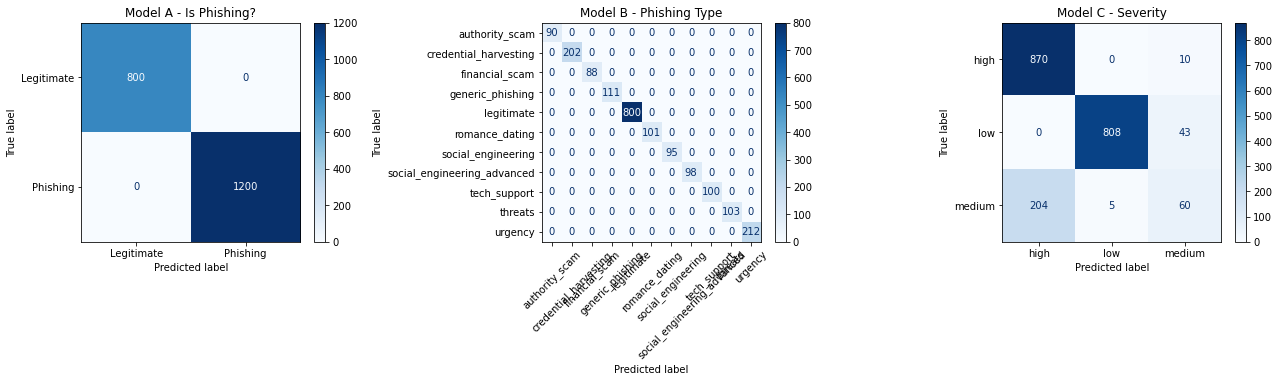

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(
    yA_test, yA_pred, display_labels=['Legitimate','Phishing'],
    cmap='Blues', ax=axes[0])
axes[0].set_title('Model A - Is Phishing?')
ConfusionMatrixDisplay.from_predictions(
    yB_test, yB_pred, display_labels=le_type.classes_,
    cmap='Blues', ax=axes[1], xticks_rotation=45)
axes[1].set_title('Model B - Phishing Type')
ConfusionMatrixDisplay.from_predictions(
    yC_test, yC_pred, display_labels=le_sev.classes_,
    cmap='Blues', ax=axes[2])
axes[2].set_title('Model C - Severity')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


### B7. SHAP — Model A Feature Importance

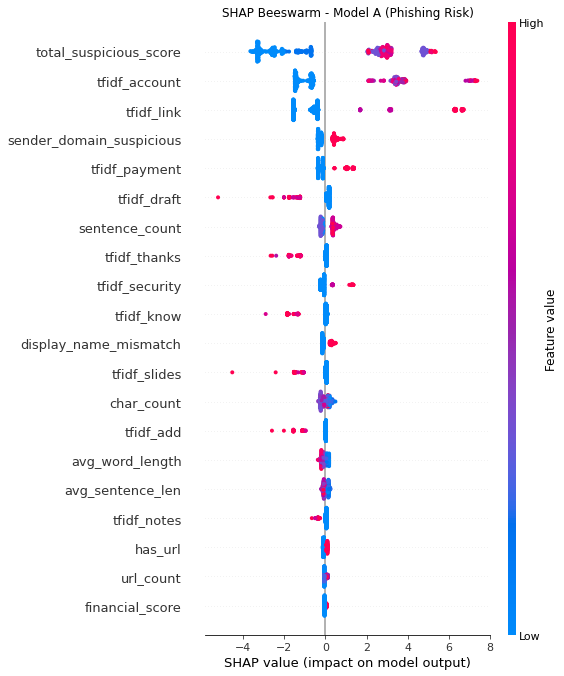

In [15]:
explainer_a   = shap.TreeExplainer(model_a)
shap_values_a = explainer_a.shap_values(X_test[:500])

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_a, X_test[:500],
                  feature_names=FEATURE_COLS, max_display=20, show=False)
plt.title('SHAP Beeswarm - Model A (Phishing Risk)')
plt.tight_layout()
plt.savefig('shap_beeswarm_modelA.png', dpi=150, bbox_inches='tight')
plt.show()


### B8. SHAP — Model B per Phishing Type

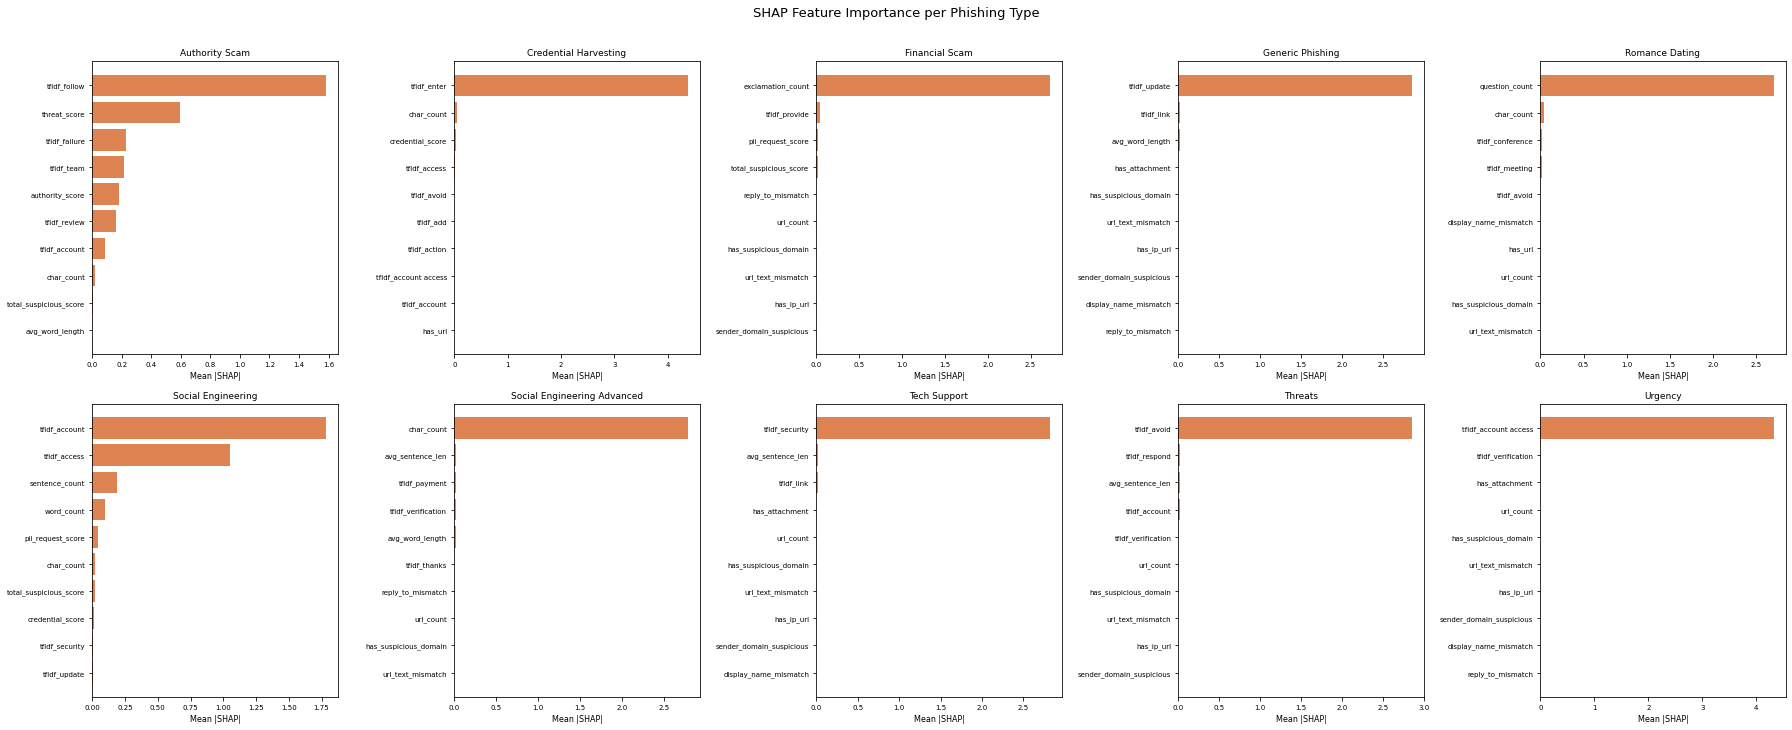

In [16]:
explainer_b   = shap.TreeExplainer(model_b)
shap_values_b = np.array(explainer_b.shap_values(X_test[:300])).transpose(1, 2, 0)

phishing_cls_idx   = [i for i, c in enumerate(le_type.classes_) if c != 'legitimate']
phishing_cls_names = [le_type.classes_[i] for i in phishing_cls_idx]

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()
for ax_i, (ci, cn) in enumerate(zip(phishing_cls_idx, phishing_cls_names)):
    sv       = shap_values_b[:, :, ci]
    mean_abs = np.abs(sv).mean(axis=0)
    top_idx  = np.argsort(mean_abs)[::-1][:10]
    axes[ax_i].barh([FEATURE_COLS[i] for i in top_idx[::-1]],
                    mean_abs[top_idx[::-1]], color='#DD8452')
    axes[ax_i].set_title(cn.replace('_',' ').title(), fontsize=9)
    axes[ax_i].set_xlabel('Mean |SHAP|', fontsize=8)
    axes[ax_i].tick_params(labelsize=7)
plt.suptitle('SHAP Feature Importance per Phishing Type', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('shap_per_type.png', dpi=150, bbox_inches='tight')
plt.show()


### B9. Save Models

In [17]:
joblib.dump(model_a,           'model_a_binary.pkl')
joblib.dump(model_b,           'model_b_type.pkl')
joblib.dump(model_c,           'model_c_severity.pkl')
joblib.dump(le_type,           'label_encoder_type.pkl')
joblib.dump(le_sev,            'label_encoder_severity.pkl')
joblib.dump(FEATURE_COLS,      'feature_cols.pkl')
joblib.dump(HAND_FEATURE_COLS, 'hand_feature_cols.pkl')

print('Saved files:')
for f in ['model_a_binary.pkl','model_b_type.pkl','model_c_severity.pkl',
          'label_encoder_type.pkl','label_encoder_severity.pkl',
          'feature_cols.pkl','hand_feature_cols.pkl','tfidf_vocabulary.pkl']:
    if os.path.exists(f):
        print(f'  {f}: {os.path.getsize(f)/1024:.1f} KB')


Saved files:
  model_a_binary.pkl: 115.1 KB
  model_b_type.pkl: 657.9 KB
  model_c_severity.pkl: 604.0 KB
  label_encoder_type.pkl: 0.7 KB
  label_encoder_severity.pkl: 0.5 KB
  feature_cols.pkl: 1.3 KB
  hand_feature_cols.pkl: 0.5 KB
  tfidf_vocabulary.pkl: 1.3 KB


---
## Cell Group C: Inference Function

Input: one raw email text string  
Output: `is_phishing` / `phishing_type` / `severity`

This function will be packaged into the final Python module.

### C1. Load Fixed TF-IDF Vocabulary

In [18]:
# Use the fixed vocabulary saved during feature engineering
vocab = joblib.load('tfidf_vocabulary.pkl')
tfidf_inference = TfidfVectorizer(
    vocabulary=vocab,
    ngram_range=(1, 2),
    sublinear_tf=True,
    token_pattern=r'\b[a-zA-Z]{2,}\b',
    stop_words='english',
)
tfidf_inference.fit(df['body'].iloc[idx_train])
TFIDF_VOCAB_COLS = [f'tfidf_{t}' for t in tfidf_inference.get_feature_names_out()]

# Mean values for synthetic features (phishing-class estimate for inference)
SYNTH_MEAN = {
    'has_url': 0.75, 'url_count': 2.0,
    'has_suspicious_domain': 0.55, 'url_text_mismatch': 0.50,
    'has_ip_url': 0.20, 'sender_domain_suspicious': 0.60,
    'display_name_mismatch': 0.45, 'reply_to_mismatch': 0.35,
    'has_attachment': 0.30,
}

print(f'TF-IDF vocabulary loaded: {len(vocab)} terms')


TF-IDF vocabulary loaded: 50 terms


### C2. Inference Feature Extraction

In [19]:
def extract_features_for_inference(raw_text: str) -> dict:
    """
    Extract features from a single raw email text for inference.
    Uses the same logic as the training feature engineering.
    Synthetic features (URL, sender) use phishing-class mean estimates.
    """
    body, _ = split_body_keywords(raw_text)
    words   = re.findall(r'\b\w+\b', body)
    sents   = [s for s in re.split(r'[.!?]+', body) if s.strip()]
    uc      = re.findall(r'\b[A-Z]{2,}\b', body)

    feat = {
        'char_count':           len(body),
        'word_count':           len(words),
        'sentence_count':       len(sents),
        'avg_word_length':      len(body)/len(words) if words else 0,
        'avg_sentence_len':     len(words)/len(sents) if sents else 0,
        'exclamation_count':    body.count('!'),
        'question_count':       body.count('?'),
        'uppercase_word_count': len(uc),
        'uppercase_ratio':      len(uc)/len(words) if words else 0,
        'special_char_count':   sum(1 for c in body if c in '@#$%^&*+=<>[]{}|\\~`'),
    }
    for fname, kw_list in LEXICONS.items():
        feat[fname] = count_keywords(body, kw_list)
    feat['total_suspicious_score'] = sum(feat[k] for k in LEXICONS)
    feat.update(SYNTH_MEAN)
    return feat

print('extract_features_for_inference() defined')


extract_features_for_inference() defined


### C3. Core Inference Function

In [27]:
def analyze_email(raw_email_text: str, show_shap: bool = False) -> dict:
    """
    Full inference pipeline for a single raw email.

    Input : raw email text (string)
    Output: dict with labels
        - is_phishing   : int   (0 = legitimate, 1 = phishing)
        - risk_score    : float (0.0 ~ 1.0)
        - phishing_type : str
        - severity      : str   ('low', 'medium', 'high')
        - top_features  : list  (only when show_shap=True)
    """
    body, _    = split_body_keywords(raw_email_text)
    hand_feat  = extract_features_for_inference(raw_email_text)
    tfidf_vec  = tfidf_inference.transform([body]).toarray()[0]
    tfidf_dict = dict(zip(TFIDF_VOCAB_COLS, tfidf_vec))
    combined   = {**hand_feat, **tfidf_dict}
    X_single   = pd.DataFrame(
        [[combined.get(c, 0.0) for c in FEATURE_COLS]],
        columns=FEATURE_COLS
    )

    is_phishing = int(model_a.predict(X_single)[0])
    risk_score  = float(model_a.predict_proba(X_single)[0, 1])

    if is_phishing == 0:
        return {
            'is_phishing':   0,
            'risk_score':    round(risk_score, 4),
            'phishing_type': 'legitimate',
            'severity':      'low'
        }

    type_proba    = model_b.predict_proba(X_single)
    type_idx      = int(model_b.predict(X_single)[0])
    phishing_type = le_type.classes_[type_idx]
    type_conf     = float(type_proba[0, type_idx])

    X_single_c = np.hstack([X_single.values, type_proba])
    sev_idx    = int(model_c.predict(X_single_c)[0])
    severity   = le_sev.classes_[sev_idx]

    result = {
        'is_phishing':     1,
        'risk_score':      round(risk_score, 4),
        'phishing_type':   phishing_type,
        'type_confidence': round(type_conf, 4),
        'severity':        severity
    }

    if show_shap:
        sv = explainer_a.shap_values(X_single)[0]
        top_features = sorted(
            [(FEATURE_COLS[i], float(X_single.iloc[0, i]), float(sv[i]))
             for i in range(len(FEATURE_COLS))
             if sv[i] > 0.005 and X_single.iloc[0, i] != 0],
            key=lambda x: x[2], reverse=True
        )[:5]
        result['top_features'] = top_features

    return result

print('analyze_email() ready')

analyze_email() ready


### C4. Demo — Analyze Sample Emails

In [28]:
test_df = df.iloc[idx_test].reset_index(drop=True)

phishing_sample = test_df[test_df['label'] == 1].iloc[0]['text']
legit_sample    = test_df[test_df['label'] == 0].iloc[0]['text']

print('=' * 50)
print('SAMPLE 1: Phishing email')
print('=' * 50)
print('Text:', phishing_sample[:200], '...')

# 呼叫時傳 show_shap=True
r1 = analyze_email(phishing_sample, show_shap=True)

for k, v in r1.items():
    if k == 'top_features':
        print(f'  {"top_features":<18}:')
        for name, val, shap_v in v:
            print(f'    {name}: {val:.3f}  (SHAP +{shap_v:.3f})')
    else:
        print(f'  {k:<18}: {v}')
        
print()
print('=' * 50)
print('SAMPLE 2: Legitimate email')
print('=' * 50)
print('Text:', legit_sample[:200], '...')
r2 = analyze_email(legit_sample)
print()
for k, v in r2.items():
    print(f'  {k:<18}: {v}')


SAMPLE 1: Phishing email
Text: Dear user, your account requires verification. To restore access, reset your password and enter your username, 2FA verification code, and recovery key.

Keywords: pin, authentication, password, userna ...
  is_phishing       : 1
  risk_score        : 0.9997
  phishing_type     : credential_harvesting
  type_confidence   : 0.9995
  severity          : high
  top_features      :
    tfidf_account: 0.230  (SHAP +3.720)
    total_suspicious_score: 5.000  (SHAP +2.789)
    sender_domain_suspicious: 0.600  (SHAP +0.405)
    char_count: 151.000  (SHAP +0.179)
    url_count: 2.000  (SHAP +0.070)

SAMPLE 2: Legitimate email
Text: Subject: Quarterly roadmap

Attaching the draft proposal. Feedback by Friday would be appreciated so we can finalize for the client.

I'll share the slides later today.

Best,
Jordan Kim ...

  is_phishing       : 0
  risk_score        : 0.001
  phishing_type     : legitimate
  severity          : low


### C5. Batch Inference on Test Set

In [29]:
# Quick batch check — run analyze_email on first 20 phishing test samples
phishing_test = test_df[test_df['label'] == 1].head(20)

batch_results = []
for _, row in phishing_test.iterrows():
    result = analyze_email(row['text'])
    result['true_type']     = row['phishing_type']
    result['true_severity'] = row['severity']
    batch_results.append(result)

batch_df = pd.DataFrame(batch_results)
print('Batch inference results (20 phishing samples):')
print(batch_df[['is_phishing','risk_score','phishing_type','true_type',
                'severity','true_severity']].to_string(index=False))

type_correct = (batch_df['phishing_type'] == batch_df['true_type']).mean()
sev_correct  = (batch_df['severity'] == batch_df['true_severity']).mean()
print(f'\nType accuracy (sample): {type_correct:.2%}')
print(f'Severity accuracy (sample): {sev_correct:.2%}')


Batch inference results (20 phishing samples):
 is_phishing  risk_score         phishing_type             true_type severity true_severity
           1      0.9997 credential_harvesting credential_harvesting     high          high
           1      0.9998               urgency               urgency     high        medium
           1      0.9998               urgency               urgency     high          high
           1      0.9996               threats               threats     high          high
           1      0.9996 credential_harvesting credential_harvesting     high          high
           1      0.9996 credential_harvesting credential_harvesting     high          high
           1      0.9996        authority_scam        authority_scam     high          high
           1      0.9997               urgency               urgency     high        medium
           1      0.9998               urgency               urgency     high        medium
           1      0.9997         